# Chương 7 & 8 - Phân lớp bệnh tiểu đường

So sánh Raw, MinMax, Standard + biểu đồ đánh giá

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import roc_curve, auc, precision_recall_curve

In [2]:
df = pd.read_csv("pima-indians-diabetes.csv")

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [3]:
mm = MinMaxScaler()
st = StandardScaler()

X_train_mm = mm.fit_transform(X_train)
X_test_mm = mm.transform(X_test)

X_train_st = st.fit_transform(X_train)
X_test_st = st.transform(X_test)

In [4]:
model = LogisticRegression(max_iter=1000)

results = {}
preds = {}
probs = {}

# RAW
model.fit(X_train, y_train)
preds["Raw"] = model.predict(X_test)
probs["Raw"] = model.predict_proba(X_test)[:,1]
results["Raw"] = accuracy_score(y_test, preds["Raw"])

# MinMax
model.fit(X_train_mm, y_train)
preds["MinMax"] = model.predict(X_test_mm)
probs["MinMax"] = model.predict_proba(X_test_mm)[:,1]
results["MinMax"] = accuracy_score(y_test, preds["MinMax"])

# Standard
model.fit(X_train_st, y_train)
preds["Standard"] = model.predict(X_test_st)
probs["Standard"] = model.predict_proba(X_test_st)[:,1]
results["Standard"] = accuracy_score(y_test, preds["Standard"])

print(results)

{'Raw': 0.8116883116883117, 'MinMax': 0.8051948051948052, 'Standard': 0.8116883116883117}


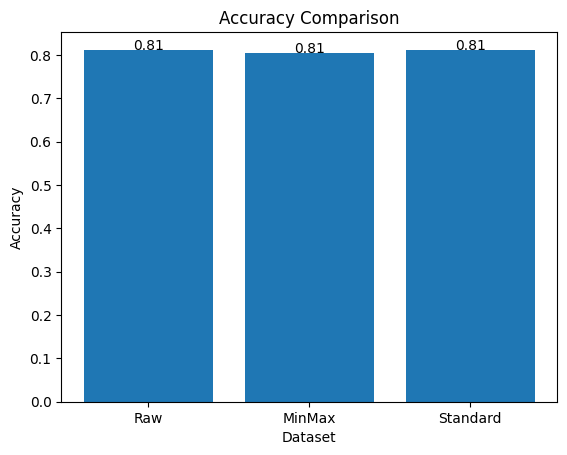

In [5]:
# Accuracy Chart
plt.figure()
plt.bar(results.keys(), results.values())
plt.title("Accuracy Comparison")
plt.xlabel("Dataset")
plt.ylabel("Accuracy")

for i, v in enumerate(results.values()):
    plt.text(i, v, f"{v:.2f}", ha='center')

plt.show()

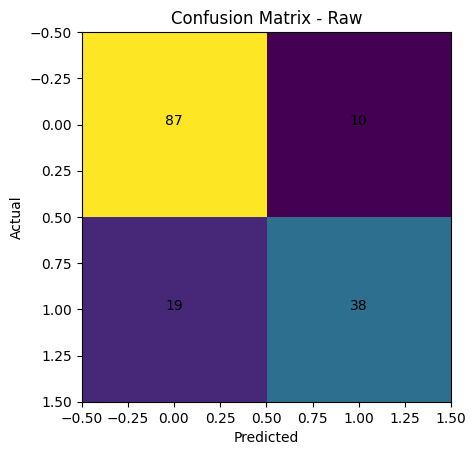

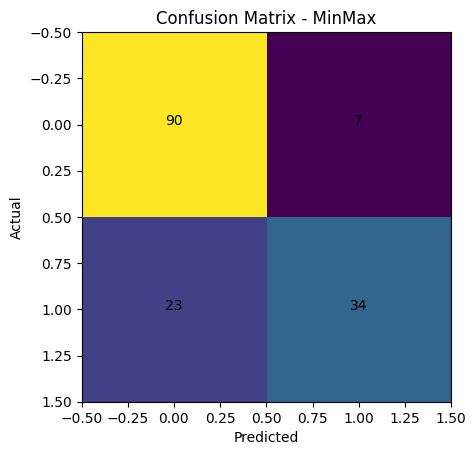

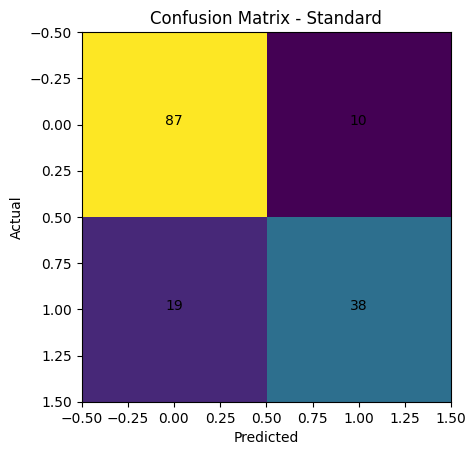

In [6]:
# Confusion Matrix
for key in preds:
    cm = confusion_matrix(y_test, preds[key])

    plt.figure()
    plt.imshow(cm)
    plt.title(f"Confusion Matrix - {key}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha='center')

    plt.show()

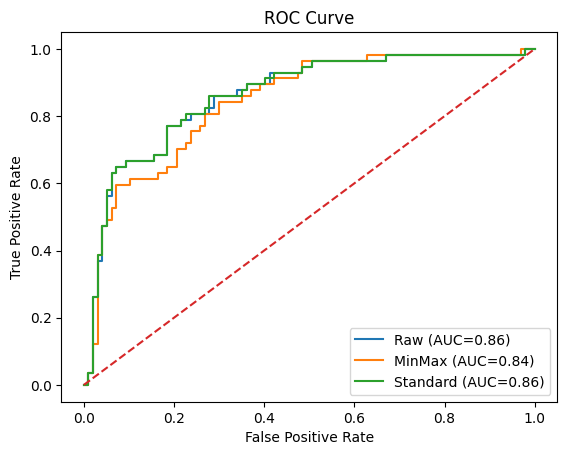

In [7]:
# ROC Curve
plt.figure()

for key in probs:
    fpr, tpr, _ = roc_curve(y_test, probs[key])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{key} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

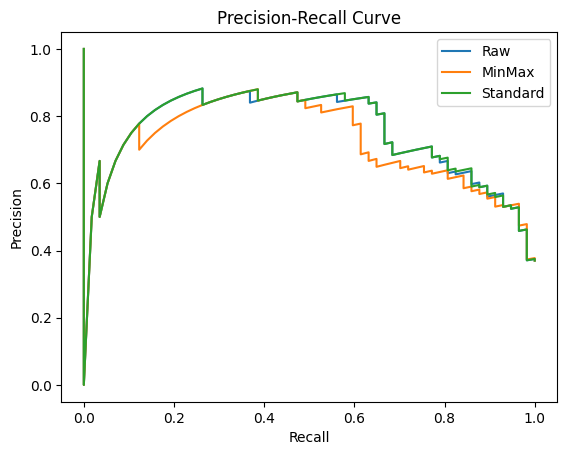

In [8]:
# Precision-Recall Curve
plt.figure()

for key in probs:
    precision, recall, _ = precision_recall_curve(y_test, probs[key])
    plt.plot(recall, precision, label=key)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()